Hospital Clustering Analysis

In [1]:
# Objective

# To group hospitals into meaningful clusters based on performance patterns.

# This helps identify distinct hospital segments such as high-performing,
# low-performing, and inconsistent hospitals.

# Questions addressed:

# 1- Can hospitals be grouped based on performance similarity?
# 2- What characteristics define each cluster?
# 3- Are there hidden patterns not visible in EDA?

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import sys
import os


In [3]:
df=pd.read_csv("../data/processed/cleaned_master_data.csv")

In [4]:
df.head()

,value,data_period,hospital_name,state,hospital_type,measure_code,measure_name,unit,reported_measure_name
0,108.00,2022-23,Byron Central Hospital,New South Wales,Local Hospital Network,Myh0006,Number Of Elective Surgeries,Surgeries,Urgent Elective Surgery
1,25.00,2022-23,Royal Rehabilitation Hospital,New South Wales,Local Hospital Network,Myh0006,Number Of Elective Surgeries,Surgeries,Laryngectomy
2,75.00,2022-23,Wingham Hospital,New South Wales,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Curettage And Evacuation Of Uterus
3,1620.00,2022-23,Launceston General Hospital,Tasmania,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Common Peroneal Nerve Release
4,85.16,2022-23,South West Healthcare [Camperdown],Victoria,Local Hospital Network,Myh0009,Median Waiting Time For Elective Surgery,Days,Procedure For Strabismus (Squint Repair)


In [10]:
if "measure_category" not in df.columns:
  sys.path.append(os.path.abspath(".."))
  from utils.feature_engineering import classify_measure
  df["measure_category"]=df["measure_name"].apply(classify_measure)

In [18]:
df_pct=df[df["measure_category"]=="percentage"].copy()
df_pct.head()

,value,data_period,hospital_name,state,hospital_type,measure_code,measure_name,unit,reported_measure_name,measure_category
2,75.00,2022-23,Wingham Hospital,New South Wales,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Curettage And Evacuation Of Uterus,percentage
3,1620.00,2022-23,Launceston General Hospital,Tasmania,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Common Peroneal Nerve Release,percentage
6,19.00,2022-23,Coolamon-Ganmain Multi Purpose Service,New South Wales,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Cholecystectomy (Open/Laparoscopic),percentage
16,41.00,2022-23,Ballarat Health Services [Base Hospital],Victoria,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Discectomy,percentage
19,84.89,2022-23,The Tweed Hospital,New South Wales,Local Hospital Network,Myh0007,Percentage Of Patients Who Waited Longer Than ...,Percent,Ganglion - Excision Of,percentage


Creating Hospital Feature Matrix

In [19]:
hospital_matrix=df_pct.pivot_table(
  index='hospital_name',
  columns='measure_name',
  values='value',
  aggfunc='mean'
)
hospital_matrix.head()
print(f"Original shape: {hospital_matrix.shape}")

Original shape: (727, 10)


In [20]:
# mean imputation for missing values
hospital_matrix=hospital_matrix.fillna(hospital_matrix.mean())

Scaling Hospital Matrix

In [21]:
scaler=StandardScaler()
hospital_matrix_scaled=scaler.fit_transform(hospital_matrix)

Finding Optimal K

In [22]:
# We use the elbow method to balance model complexity and cluster compactness.
# This helps us choose a K that captures meaningful patterns without overfitting or underfitting the data.
inertia=[]
K_range=range(1,10)
for k in K_range:
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(hospital_matrix_scaled)
  inertia.append(kmeans.inertia_)

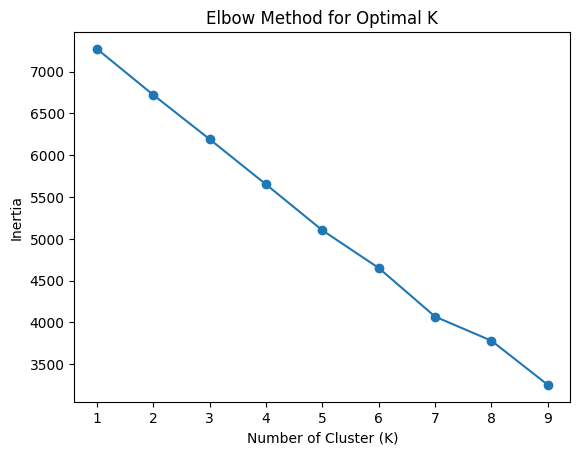

In [23]:
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Cluster (K)')
plt.ylabel('Inertia')
plt.show()

Applying K Means

In [ ]:
# Taking elbow point as 5 as it is the point where inertia starts to decrease more slowly
# it is the last point where adding anotehr cluster improves the grouping
# after that the improvements are minimal and curve starts to level off
kmeans=KMeans(n_clusters=5, random_state=42)
clusters=kmeans.fit_predict(hospital_matrix_scaled)
hospital_matrix['cluster']=clusters